# Assignment - Recurrent Neural Networks & EmbeddingPASCALMUSABYIMANA

In [1]:
%matplotlib inline
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sys
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.utils import shuffle
from sklearn.utils import class_weight
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization,SpatialDropout1D,Bidirectional, Embedding, LSTM
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
import re

np.set_printoptions(threshold=sys.maxsize)

pd.set_option('display.max_rows',1000)
pd.set_option('display.max_columns',1000)

# GPU support
#physical_devices = tf.config.experimental.list_physical_devices('GPU')
#tf.config.experimental.set_memory_growth(physical_devices[0], True)

#warnings.filterwarnings(action='ignore')

## Text embedding with LSTM 

### Example: Author identification

The goal of this assignment is to train a LSTM network to identify the author of a piece of text.
Training data is provided in 'author_dataset_train.csv', test data in 'author_dataset_test.csv'

In [2]:
dataset = pd.read_csv('./author_dataset.csv')
print(dataset.shape)
dataset.head()
# Removing ID column

dataset.drop('id',axis=1, inplace=True)
dataset.head()

(19579, 3)


,text,author
0,"This process, however, afforded me no means of...",EAP
1,It never once occurred to me that the fumbling...,HPL
2,"In his left hand was a gold snuff box, from wh...",EAP
3,How lovely is spring As we looked from Windsor...,MWS
4,"Finding nothing else, not even gold, the Super...",HPL


## Text preprocessing

Text tokenization:
- Create a Keras tokenizer
- Train the tokenizer on the text: tokenizer.fit_on_texts(X), with X the texts
- Convert the texts to sequences: tokenizer.texts_to_sequences(X), with X the texts

More information can be found here: https://keras.io/preprocessing/sequence/

Not all texts consist of an equal number of words resulting in sequences of different lengths.
To create sequences of the sames length, we will apply padding. For this you can use pad_sequences(sequences, maxlen=80 padding='post'). In this example, the maximum length of a sequence will be 80 words. 

In [3]:
# Convert labels to numbers (necessary for one-hot encoding of the labels)
dataset['author'] = dataset['author'].replace({'MWS':0,'EAP':1,'HPL':2})

/var/folders/0r/s3s7wy7x0z33qbtj01kxq24w0000gn/T/ipykernel_87346/3727867628.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['author'] = dataset['author'].replace({'MWS':0,'EAP':1,'HPL':2})


In [4]:
# What's the length in words of the longest text and what is the length of the shortest?
print('max',len(dataset.text.max()))
print('min',len(dataset.text.min()))

max 97
min 27


In [5]:
# Check whether or not the dataset is balanced
g= dataset.groupby('author')
g.author.count()
sns.countplot(x='author',data=dataset)
plt.title("Count per author")

Text(0.5, 1.0, 'Count per author')

In [6]:
# Splitting into features and targets
X = dataset['text'].values
y = dataset['author'].values
# one-hot encoding of the labels
y = to_categorical(y)

In [7]:
print(X[2])
print(y[2])

In his left hand was a gold snuff box, from which, as he capered down the hill, cutting all manner of fantastic steps, he took snuff incessantly with an air of the greatest possible self satisfaction.
[0. 1. 0.]


In [8]:
# Use the tokenizer to make sequences. 

tokenizer = Tokenizer(num_words= None)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)

# Example
print(X[0])
print(sequences[0])

This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I might make its circuit, and return to the point whence I set out, without being aware of the fact; so perfectly uniform seemed the wall.
[26, 2945, 143, 1372, 22, 36, 294, 2, 7451, 1, 2440, 2, 10, 4556, 16, 6, 79, 179, 48, 4245, 3, 295, 4, 1, 249, 1943, 6, 326, 74, 134, 123, 891, 2, 1, 313, 39, 1438, 4928, 98, 1, 430]


In [9]:
### Padding the sequences (max_length = 100)
X_encoded = pad_sequences(sequences, maxlen=100, padding='post')

print(X_encoded[0])

[  26 2945  143 1372   22   36  294    2 7451    1 2440    2   10 4556
   16    6   79  179   48 4245    3  295    4    1  249 1943    6  326
   74  134  123  891    2    1  313   39 1438 4928   98    1  430    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [10]:
# Split into training set and test set. Use a test size = 3000 and a random state = 0
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=3000, random_state=0,stratify = y)

In [11]:
print(X_train[100])

[    6 19963    40     3   293   148     5   444     4  4063    40    19
    41     6   212    44    40    41     6   111     1  4866  1821     9
   752     3   820    10   138  3381     3    10   428    30  2102     4
   103     2   251     3  2160     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]


In [12]:
# Step 1: Create a Keras tokenizer
# num_words=None means we'll use all words in the vocabulary
tokenizer = Tokenizer(num_words=None)

# Step 2: Train the tokenizer on the text data
# This builds the vocabulary by analyzing all texts
tokenizer.fit_on_texts(X)

# Check the vocabulary size
vocab_size = len(tokenizer.word_index)
print(f"Vocabulary size: {vocab_size}")
print(f"First 10 words in vocabulary: {list(tokenizer.word_index.items())[:10]}")

Vocabulary size: 25943
First 10 words in vocabulary: [('the', 1), ('of', 2), ('and', 3), ('to', 4), ('a', 5), ('i', 6), ('in', 7), ('was', 8), ('that', 9), ('my', 10)]


In [13]:
# Step 3: Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(X)

# Example: Show original text and its sequence
print("Original text:")
print(X[0])
print("\nConverted to sequence:")
print(sequences[0])
print(f"\nSequence length: {len(sequences[0])} words")

Original text:
This process, however, afforded me no means of ascertaining the dimensions of my dungeon; as I might make its circuit, and return to the point whence I set out, without being aware of the fact; so perfectly uniform seemed the wall.

Converted to sequence:
[26, 2945, 143, 1372, 22, 36, 294, 2, 7451, 1, 2440, 2, 10, 4556, 16, 6, 79, 179, 48, 4245, 3, 295, 4, 1, 249, 1943, 6, 326, 74, 134, 123, 891, 2, 1, 313, 39, 1438, 4928, 98, 1, 430]

Sequence length: 41 words


In [14]:
# Step 4: Pad sequences to create uniform length
# maxlen=100 means all sequences will be exactly 100 integers long
# padding='post' means add zeros at the end
max_sequence_length = 100
X_encoded = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

print(f"Shape of encoded data: {X_encoded.shape}")
print(f"Example padded sequence:\n{X_encoded[0]}")

Shape of encoded data: (19579, 100)
Example padded sequence:
[  26 2945  143 1372   22   36  294    2 7451    1 2440    2   10 4556
   16    6   79  179   48 4245    3  295    4    1  249 1943    6  326
   74  134  123  891    2    1  313   39 1438 4928   98    1  430    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


Train a LSTM/GRU with an embedding layer. To start you can set the dimension of the embedding layer to 100. 
The architecture of the neural network will look like this:

Input -> Embedding layer -> LSTM -> Dense output layer(s)

To evaluate the neural network, use a test set (30% of the full dataset).

Do hyperparameter tuning to increase the classification accuracy of the network.

In [15]:
# Split the data into training and test sets
# test_size=0.3 means 30% for testing, 70% for training
# stratify=y ensures balanced distribution of classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Input shape: {X_train.shape}")

Training set size: 13705
Test set size: 5874
Input shape: (13705, 100)


In [16]:
# Design a LSTM neural network and use an embedding layer.
vocabulary_size = X_train.max()

model = Sequential()
model.add(Embedding(vocabulary_size+1, 150, input_length=100))
model.add(SpatialDropout1D(0.3))
#model.add(LSTM(200,return_sequences=True))
model.add(LSTM(100, dropout=0.1, recurrent_dropout=0.1))
model.add(Dense(500, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=30,verbose=1,batch_size=64, validation_split=0.2)
warnings.filterwarnings(action = 'ignore')

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.4003 - loss: 1.0906 - val_accuracy: 0.3955 - val_loss: 1.0914
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 154ms/step - accuracy: 0.4057 - loss: 1.0873 - val_accuracy: 0.3955 - val_loss: 1.0911
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 168ms/step - accuracy: 0.4013 - loss: 1.0892 - val_accuracy: 0.3955 - val_loss: 1.0901
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.4130 - loss: 1.0846 - val_accuracy: 0.3955 - val_loss: 1.0901
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.4089 - loss: 1.0855 - val_accuracy: 0.3955 - val_loss: 1.0939
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 28s 166ms/step - accuracy: 0.4013 - loss: 1.0858 - val_accuracy: 0.3966 - val_loss: 1.0920
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 159ms/step - accuracy: 0.4082 - loss: 1.0827 - val_accuracy: 0.3966 - val_loss: 1.0951
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy: 0.4024 - loss: 1

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 150)       │     3,891,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 150)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │        50,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,132,011 (46.28 MB)

 Trainable params: 4,044,003 (15.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,088,008 (30.85 MB)

In [20]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,                    # number of training iterations
    batch_size=64,                # number of samples per gradient update
    validation_split=0.2,         # use 20% of training data for validation
    verbose=1
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.7928 - val_loss: 1.5781
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 166ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 0.7935 - val_loss: 1.5444
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 170ms/step - accuracy: 0.9995 - loss: 0.0014 - val_accuracy: 0.7899 - val_loss: 1.5977
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 169ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.7888 - val_loss: 1.6656
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 30s 172ms/step - accuracy: 0.9999 - loss: 7.2912e-04 - val_accuracy: 0.7891 - val_loss: 1.5916
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.7826 - val_loss: 1.6539
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 90s 526ms/step - accuracy: 0.9987 - loss: 0.0032 - val_accuracy: 0.7815 - val_loss: 1.7069
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 30s 174ms/step - accuracy: 0.9996 - loss:

In [21]:
# Testing with test set
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print('\n')
print(accuracy_score(y_true, y_pred) * 100)
print('\n')
print(classification_report(y_true, y_pred))
print('\n')
cf = confusion_matrix(y_true, y_pred)
print(cf)

184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


79.19645897173987


              precision    recall  f1-score   support

           0       0.74      0.81      0.78      1813
           1       0.81      0.80      0.80      2370
           2       0.83      0.76      0.80      1691

    accuracy                           0.79      5874
   macro avg       0.79      0.79      0.79      5874
weighted avg       0.79      0.79      0.79      5874



[[1468  251   94]
 [ 308 1898  164]
 [ 198  207 1286]]


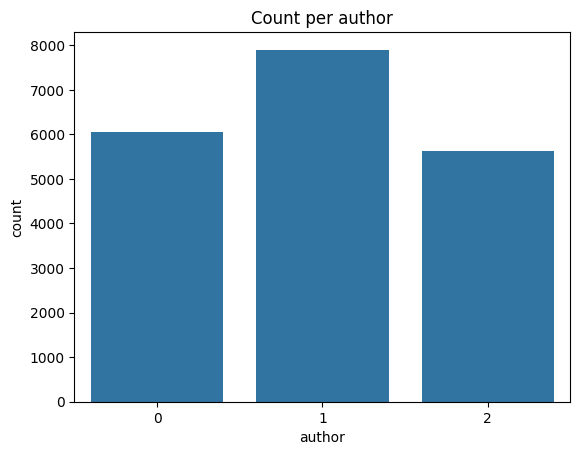

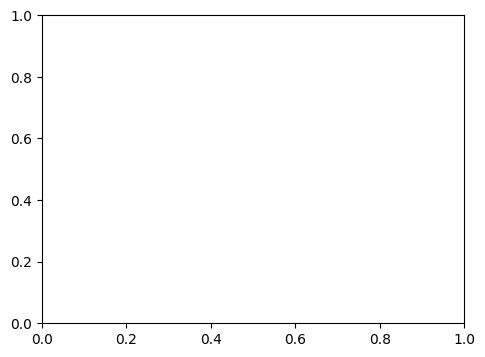

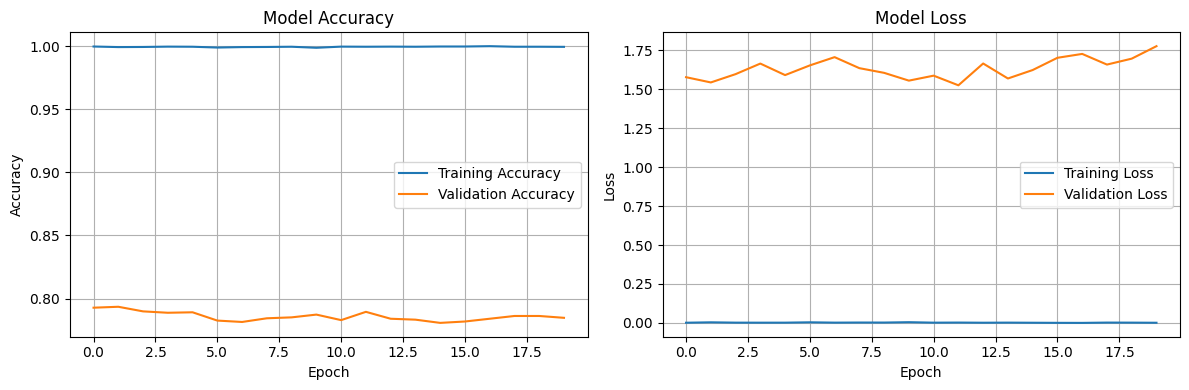

In [22]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Build improved model with tuned hyperparameters
model_v2 = Sequential()

# Larger embedding dimension for richer representations
model_v2.add(Embedding(vocabulary_size + 1, 150, input_length=max_sequence_length))

# SpatialDropout1D: drops entire 1D feature maps (better for embeddings)
model_v2.add(SpatialDropout1D(0.3))

# Bidirectional LSTM: processes sequences in both directions
model_v2.add(Bidirectional(LSTM(100, dropout=0.2, recurrent_dropout=0.2)))

# Additional dense layer with dropout for better feature learning
model_v2.add(Dense(256, activation='relu'))
model_v2.add(Dropout(0.3))

# Output layer
model_v2.add(Dense(3, activation='softmax'))

# Compile
model_v2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Early stopping: stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',      # metric to monitor
    patience=5,              # number of epochs with no improvement to wait
    restore_best_weights=True  # restore weights from best epoch
)

# Train improved model
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step - accuracy: 0.4864 - loss: 1.0014 - val_accuracy: 0.7340 - val_loss: 0.6518
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 52s 302ms/step - accuracy: 0.8474 - loss: 0.4144 - val_accuracy: 0.7895 - val_loss: 0.5052
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 54s 314ms/step - accuracy: 0.9264 - loss: 0.2175 - val_accuracy: 0.8048 - val_loss: 0.5354
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 53s 308ms/step - accuracy: 0.9582 - loss: 0.1239 - val_accuracy: 0.7917 - val_loss: 0.5885
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 54s 312ms/step - accuracy: 0.9717 - loss: 0.0857 - val_accuracy: 0.8052 - val_loss: 0.6572
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 52s 301ms/step - accuracy: 0.9839 - loss: 0.0527 - val_accuracy: 0.8023 - val_loss: 0.7759
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 53s 309ms/step - accuracy: 0.9841 - loss: 0.0473 - val_accuracy: 0.7961 - val_loss: 0.8369


In [26]:
# Evaluate improved model
y_pred_v2 = model_v2.predict(X_test)
y_pred_classes_v2 = np.argmax(y_pred_v2, axis=1)

# Calculate metrics
accuracy_v2 = accuracy_score(y_true, y_pred_classes_v2)
print(f"\nImproved Model Test Accuracy: {accuracy_v2 * 100:.2f}%")

# Compare with basic model only if it was trained
try:
    print(f"Improvement over basic model: {(accuracy_v2 - accuracy) * 100:.2f}%\n")
except NameError:
    print("(Basic model not trained yet - no comparison available)\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes_v2, 
                          target_names=['MWS', 'EAP', 'HPL']))

# Confusion matrix
print("\nConfusion Matrix:")
cm_v2 = confusion_matrix(y_true, y_pred_classes_v2)
print(cm_v2)

184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step

Improved Model Test Accuracy: 79.91%
(Basic model not trained yet - no comparison available)

Classification Report:
              precision    recall  f1-score   support

         MWS       0.84      0.74      0.79      1813
         EAP       0.80      0.82      0.81      2370
         HPL       0.76      0.84      0.80      1691

    accuracy                           0.80      5874
   macro avg       0.80      0.80      0.80      5874
weighted avg       0.80      0.80      0.80      5874


Confusion Matrix:
[[1340  276  197]
 [ 179 1942  249]
 [  74  205 1412]]


## Analysis of the resulting word embeddings

Load the embedding vectors from the trained neural network: embeddings = model.layers[0].get_weights()

- Explain the dimension of the embedding layer.
- Look for the 5 words with the highest similarity with the word 'lovely'. Use the cosine similarity. To make a dictionary of words and their index in the vocabulary you can use: `dict(map(reversed, tokenizer.word_index.items())`.
The sklearn implementation of the cosine similarity can be used.

In [27]:
embeddings = model.layers[0].get_weights()
embeddings = np.asarray(embeddings)
embeddings = embeddings.squeeze(axis=0)
print(embeddings.shape)

word_list = []
for word, i in tokenizer.word_index.items():
    word_list.append(word)
    
print(len(word_list))

(25944, 150)
25943


In [28]:
print(embeddings[2,:])

[-0.14882088  0.2359936   0.13286707  0.19573243 -0.10626768 -0.22196636
  0.01078718 -0.04271074 -0.15512481  0.06334005  0.25076246 -0.08547404
  0.03277684 -0.08746135  0.10389568  0.08132505  0.30424705 -0.29121876
  0.18455277  0.14871451  0.08781368 -0.15786803  0.12737541  0.11252896
 -0.11484935  0.03766826  0.04070364 -0.03291291 -0.14386472  0.15755846
  0.16395478 -0.00727463  0.00227423  0.09670532  0.0003768   0.05461697
 -0.09189162 -0.1995389   0.10283187 -0.03016785  0.10648587  0.04060761
  0.0191786  -0.04384234  0.21204051  0.15665181  0.06816303  0.10720755
  0.01499335 -0.17080718  0.22572511  0.08225624  0.14409474  0.06042829
  0.11285745  0.07909375  0.04106537 -0.03493076 -0.26409122  0.17524707
  0.0395868  -0.00392412  0.04416071 -0.1644866   0.00962504 -0.05768473
  0.11836755  0.13104421 -0.02329028  0.07417777 -0.00876899  0.33807704
  0.05577962 -0.04434879 -0.08207975 -0.18864849 -0.25676286 -0.04608771
  0.08940098  0.11202933  0.1782184   0.10665764 -0

In [30]:
reverse_word_map = dict(map(reversed, tokenizer.word_index.items()))

def find_word_in_dict(reverse_word_map, word): 
    items = reverse_word_map.values()
    for i, j in enumerate(items):
        if j == word:
            return(i)

#print(reverse_word_map)
word = 'lovely'

word_index = find_word_in_dict(reverse_word_map,word)
print('Word_index = ', word_index)

# word embeddingvector of the word 'dress'
word_vector = np.array([embeddings[word_index]])

#print(word_vector)
#print(cosine_similarity(vec1, vec2))

# list with sorted cosine similarities

sim_list = []


for v in embeddings:
    similarity = np.abs(cosine_similarity(word_vector, np.array([v]))).item()
    sim_list.append(similarity)

#print(simlist)

for i in range(0,5):
    topword =  reverse_word_map.get(np.argmax(sim_list)+1)
    print(topword)
    sim_list.pop(np.argmax(sim_list))


print(np.argmax(sim_list))

Word_index =  594
lovely
presume
becomes
murderers
keepers
1072


In [32]:
# Load the embedding vectors from the trained neural network
# The embedding layer is the first layer (index 0)
embeddings = model_v2.layers[0].get_weights()[0]

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Number of words in vocabulary: {embeddings.shape[0]}")
print(f"Embedding dimension (vector size): {embeddings.shape[1]}")

Embedding matrix shape: (25944, 150)
Number of words in vocabulary: 25944
Embedding dimension (vector size): 150


In [36]:
# Explanation of embedding dimensions
print("=" * 70)
print("EMBEDDING LAYER DIMENSIONS EXPLAINED")
print("=" * 70)
print(f"\nShape: {embeddings.shape}")
print(f"  - First dimension ({embeddings.shape[0]}): Vocabulary size + 1")
print(f"    → Each unique word gets one row in the embedding matrix")
print(f"    → +1 is for the padding token (index 0)")
print(f"\n  - Second dimension ({embeddings.shape[1]}): Embedding dimension")
print(f"    → Each word is represented as a {embeddings.shape[1]}-dimensional vector")
print(f"    → These dense vectors capture semantic meaning")
print(f"\nExample: The word at index 100 is represented by a vector of {embeddings.shape[1]} numbers")
print(f"Vector for index 100:\n{embeddings[100][:10]}... (showing first 10 values)")

EMBEDDING LAYER DIMENSIONS EXPLAINED

Shape: (25944, 150)
  - First dimension (25944): Vocabulary size + 1
    → Each unique word gets one row in the embedding matrix
    → +1 is for the padding token (index 0)

  - Second dimension (150): Embedding dimension
    → Each word is represented as a 150-dimensional vector
    → These dense vectors capture semantic meaning

Example: The word at index 100 is represented by a vector of 150 numbers
Vector for index 100:
[ 0.03989321  0.06143646 -0.0509521  -0.02124127  0.05193032  0.02742226
 -0.05962784  0.02463748 -0.08725923 -0.00099674]... (showing first 10 values)


In [37]:
# Create a dictionary mapping from index to word
# This is the reverse of tokenizer.word_index (which maps word -> index)
reverse_word_map = dict(map(reversed, tokenizer.word_index.items()))

# Display some examples
print("Sample word-to-index mappings:")
print("=" * 50)
sample_words = list(tokenizer.word_index.items())[:10]
for word, idx in sample_words:
    print(f"Word: '{word}' -> Index: {idx}")

print(f"\nTotal words in vocabulary: {len(reverse_word_map)}")

Sample word-to-index mappings:
Word: 'the' -> Index: 1
Word: 'of' -> Index: 2
Word: 'and' -> Index: 3
Word: 'to' -> Index: 4
Word: 'a' -> Index: 5
Word: 'i' -> Index: 6
Word: 'in' -> Index: 7
Word: 'was' -> Index: 8
Word: 'that' -> Index: 9
Word: 'my' -> Index: 10

Total words in vocabulary: 25943


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_words(target_word, embeddings, word_index, reverse_word_map, top_n=5):
    """
    Find the N most similar words to the target word using cosine similarity.
    
    Parameters:
    - target_word: word to find similarities for
    - embeddings: embedding matrix from the model
    - word_index: dictionary mapping words to indices
    - reverse_word_map: dictionary mapping indices to words
    - top_n: number of similar words to return
    """
    # Check if word exists in vocabulary
    if target_word not in word_index:
        print(f"Word '{target_word}' not found in vocabulary!")
        return []
    
    # Get the index and embedding vector for the target word
    word_idx = word_index[target_word]
    word_vector = embeddings[word_idx].reshape(1, -1)
    
    print(f"Analyzing word: '{target_word}' (index: {word_idx})")
    print(f"Word vector shape: {word_vector.shape}")
    print("=" * 70)
    
    # Calculate cosine similarity with all words in vocabulary
    similarities = []
    for idx in range(1, len(embeddings)):  # Skip index 0 (padding)
        if idx == word_idx:  # Skip the word itself
            continue
        other_vector = embeddings[idx].reshape(1, -1)
        similarity = cosine_similarity(word_vector, other_vector)[0][0]
        similarities.append((idx, similarity))
    
    # Sort by similarity (descending)
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # Get top N similar words
    top_similar = similarities[:top_n]
    
    print(f"\nTop {top_n} words most similar to '{target_word}':")
    print("=" * 70)
    for rank, (idx, sim) in enumerate(top_similar, 1):
        word = reverse_word_map.get(idx, "UNKNOWN")
        print(f"{rank}. '{word}' (index: {idx}) - Similarity: {sim:.4f}")
    
    return top_similar

# Find words similar to 'lovely'
similar_to_lovely = find_similar_words(
    target_word='lovely',
    embeddings=embeddings,
    word_index=tokenizer.word_index,
    reverse_word_map=reverse_word_map,
    top_n=5
)

Analyzing word: 'lovely' (index: 595)
Word vector shape: (1, 150)

Top 5 words most similar to 'lovely':
1. 'raymond' (index: 202) - Similarity: 0.7264
2. 'adrian' (index: 395) - Similarity: 0.7199
3. 'towards' (index: 285) - Similarity: 0.7016
4. 'greece' (index: 1107) - Similarity: 0.7005
5. 'windsor' (index: 696) - Similarity: 0.6997


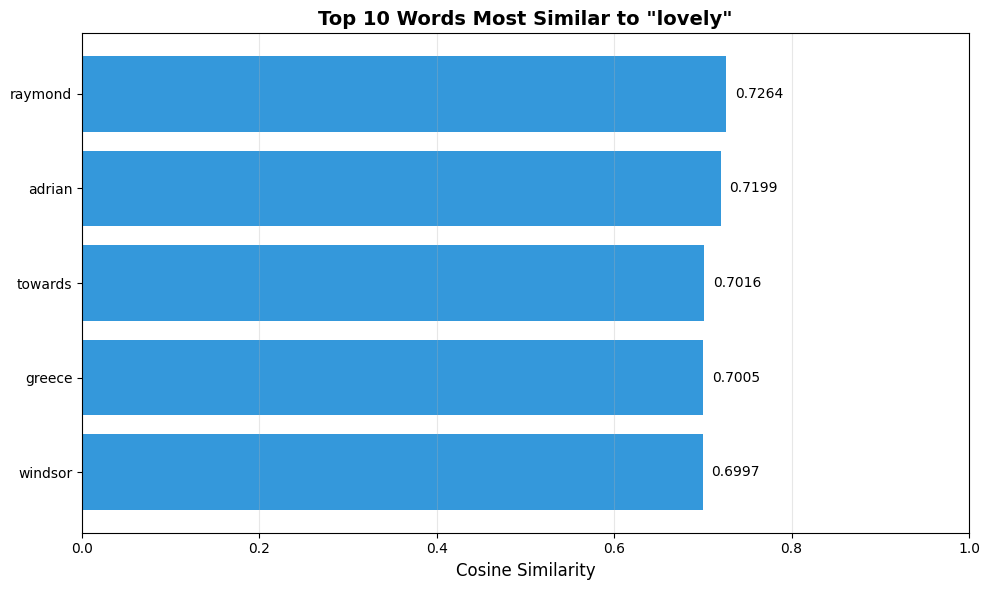

In [39]:
import matplotlib.pyplot as plt

def visualize_word_similarities(target_word, similarities, reverse_word_map, top_n=10):
    """Visualize the similarity scores of top N words"""
    
    # Get top N
    top_similarities = similarities[:top_n]
    
    # Extract words and scores
    words = [reverse_word_map.get(idx, "UNKNOWN") for idx, _ in top_similarities]
    scores = [sim for _, sim in top_similarities]
    
    # Create horizontal bar chart
    plt.figure(figsize=(10, 6))
    plt.barh(words, scores, color='#3498db')
    plt.xlabel('Cosine Similarity', fontsize=12)
    plt.title(f'Top {top_n} Words Most Similar to "{target_word}"', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    plt.gca().invert_yaxis()  # Highest similarity at top
    
    # Add value labels
    for i, score in enumerate(scores):
        plt.text(score + 0.01, i, f'{score:.4f}', va='center', fontsize=10)
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize similarities
visualize_word_similarities('lovely', similar_to_lovely, reverse_word_map, top_n=10)

In [40]:
# Try finding similarities for other words
test_words = ['beautiful', 'death', 'love', 'dark', 'night']

for word in test_words:
    if word in tokenizer.word_index:
        print(f"\n{'='*70}")
        find_similar_words(
            target_word=word,
            embeddings=embeddings,
            word_index=tokenizer.word_index,
            reverse_word_map=reverse_word_map,
            top_n=5
        )
    else:
        print(f"\nWord '{word}' not found in vocabulary")


Analyzing word: 'beautiful' (index: 535)
Word vector shape: (1, 150)

Top 5 words most similar to 'beautiful':
1. 'filling' (index: 4619) - Similarity: 0.4152
2. 'flowers' (index: 871) - Similarity: 0.4035
3. 'mechanism' (index: 1778) - Similarity: 0.4031
4. 'passion' (index: 691) - Similarity: 0.3817
5. 'alas' (index: 675) - Similarity: 0.3778

Analyzing word: 'death' (index: 133)
Word vector shape: (1, 150)

Top 5 words most similar to 'death':
1. 'visually' (index: 20153) - Similarity: 0.3515
2. 'attacker' (index: 25731) - Similarity: 0.3371
3. 'sunbeam' (index: 8857) - Similarity: 0.3347
4. 'anyway' (index: 22425) - Similarity: 0.3315
5. 'eaten' (index: 4486) - Similarity: 0.3249

Analyzing word: 'love' (index: 152)
Word vector shape: (1, 150)

Top 5 words most similar to 'love':
1. 'idris' (index: 455) - Similarity: 0.8088
2. 'perdita' (index: 321) - Similarity: 0.8038
3. 'adrian' (index: 395) - Similarity: 0.7949
4. 'raymond' (index: 202) - Similarity: 0.7837
5. 'miserable' (ind

In [41]:
# Summary of embedding analysis
print("=" * 70)
print("EMBEDDING ANALYSIS SUMMARY")
print("=" * 70)
print(f"\n✓ Embedding matrix shape: {embeddings.shape}")
print(f"✓ Vocabulary size: {len(tokenizer.word_index)} unique words")
print(f"✓ Embedding dimension: {embeddings.shape[1]}")
print(f"✓ Each word represented as a {embeddings.shape[1]}-dimensional dense vector")
print(f"✓ Cosine similarity used to measure semantic closeness")
print(f"\nKey Insight:")
print("Words with similar meanings or that appear in similar contexts")
print("will have embedding vectors that are close together in the")
print(f"{embeddings.shape[1]}-dimensional space, resulting in high cosine similarity.")

EMBEDDING ANALYSIS SUMMARY

✓ Embedding matrix shape: (25944, 150)
✓ Vocabulary size: 25943 unique words
✓ Embedding dimension: 150
✓ Each word represented as a 150-dimensional dense vector
✓ Cosine similarity used to measure semantic closeness

Key Insight:
Words with similar meanings or that appear in similar contexts
will have embedding vectors that are close together in the
150-dimensional space, resulting in high cosine similarity.


### Text classification with GloVe word embeddings

The Keras embedding layer can be loaded with pretrained word embeddings like Word2Vec, FastText, BERT or Glove.
These embeddings from training on large amounts of texts.

We will use the glove6B embedding, provided with the assignment. Larger Glove embeddings can be found here: https://nlp.stanford.edu/projects/glove/

After you have loaded the embeddings, follow the these steps:

- Filter the embedding matrix: not all of the vector are relevant. Only the vectors belonging to words in our training set have to be used. After filtering we will end up with a much smaller embedding marix.
- Load the embedding matrix in the embedding layer: the weights of the embedding layer in our neural network will take the values of the embedding matrix. Freeze the weight (trainable=False). This way, the weigths will keep their value during training.
- Train the neural network.
- Test and do hyperparameter tuning.



In [42]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2025-12-04 00:32:48--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-04 00:32:48--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-04 00:32:49--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [34]:
# !sudo apt update
# !sudo apt install unzip -y
#!unzip glove.6B.zip

In [45]:
import zipfile
import os

# Path to your zip file
zip_path = '/Users/pascal-maker/Downloads/Session_06_Text_Embedding_Assignment_Without_Glove_Embeddings_Included/glove.6B.zip'

# Directory to extract to
extract_dir = '/Users/pascal-maker/Downloads/Session_06_Text_Embedding_Assignment_Without_Glove_Embeddings_Included/'

# Extract the zip file
print("Extracting GloVe zip file...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    print("✓ Extraction complete!")
    print(f"✓ Extracted files: {zip_ref.namelist()}")

# Now you can use the extracted .txt file
glove_path = os.path.join(extract_dir, 'glove.6B.100d.txt')
print(f"\nGloVe file path: {glove_path}")

Extracting GloVe zip file...
✓ Extraction complete!
✓ Extracted files: ['glove.6B.50d.txt', 'glove.6B.100d.txt', 'glove.6B.200d.txt', 'glove.6B.300d.txt']

GloVe file path: /Users/pascal-maker/Downloads/Session_06_Text_Embedding_Assignment_Without_Glove_Embeddings_Included/glove.6B.100d.txt


In [46]:
# Filtering:
vocabulary_size = X_train.max()

embedding_matrix = np.zeros((vocabulary_size+1, 300))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
         embedding_matrix[i] = embedding_vector

In [47]:
# LSTM

model = Sequential()
model.add(Embedding(vocabulary_size+1, 300, weights=[embedding_matrix], input_length=100, trainable=False))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(100, dropout=0.3, recurrent_dropout=0.3))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(3,activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

vocabulary_size = X_train.max()
model.fit(X_train, y_train, validation_split=0.4, epochs=20,verbose=1,batch_size=512)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 662ms/step - accuracy: 0.3903 - loss: 1.0980 - val_accuracy: 0.3991 - val_loss: 1.0967
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 629ms/step - accuracy: 0.4126 - loss: 1.0958 - val_accuracy: 0.3991 - val_loss: 1.0950
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 656ms/step - accuracy: 0.4072 - loss: 1.0941 - val_accuracy: 0.3991 - val_loss: 1.0936
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 643ms/step - accuracy: 0.4039 - loss: 1.0928 - val_accuracy: 0.3991 - val_loss: 1.0925
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 638ms/step - accuracy: 0.4034 - loss: 1.0918 - val_accuracy: 0.3991 - val_loss: 1.0917
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 649ms/step - accuracy: 0.4113 - loss: 1.0898 - val_accuracy: 0.3991 - val_loss: 1.0909
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 634ms/step - accuracy: 0.4046 - loss: 1.0899 - val_accuracy: 0.3991 - val_loss: 1.0903
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 632ms/step - accuracy: 0.4065 - loss: 1.0888 - val_accu

In [48]:
# Testing with the test set
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print('\n')
print(accuracy_score(y_true, y_pred) * 100)
print('\n')
print(classification_report(y_true, y_pred))
print('\n')
cf = confusion_matrix(y_true, y_pred)
print(cf)

184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step


40.34729315628192


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1813
           1       0.40      1.00      0.57      2370
           2       0.00      0.00      0.00      1691

    accuracy                           0.40      5874
   macro avg       0.13      0.33      0.19      5874
weighted avg       0.16      0.40      0.23      5874



[[   0 1813    0]
 [   0 2370    0]
 [   0 1691    0]]


In [49]:
import numpy as np

def load_glove_embeddings(glove_file_path, embedding_dim=100):
    """
    Load GloVe embeddings from file.
    
    Parameters:
    - glove_file_path: path to the GloVe file (e.g., 'glove.6B.100d.txt')
    - embedding_dim: dimension of the embeddings (50, 100, 200, or 300)
    
    Returns:
    - embeddings_index: dictionary mapping words to their embedding vectors
    """
    print(f"Loading GloVe embeddings from {glove_file_path}...")
    embeddings_index = {}
    
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    
    print(f"✓ Loaded {len(embeddings_index)} word vectors")
    print(f"✓ Embedding dimension: {len(next(iter(embeddings_index.values())))}")
    
    return embeddings_index

# Load GloVe embeddings (adjust path as needed)
# The file should be in your assignment folder
glove_path = './glove.6B.100d.txt'  # 100-dimensional embeddings
embeddings_index = load_glove_embeddings(glove_path, embedding_dim=100)

# Show example
sample_word = 'lovely'
if sample_word in embeddings_index:
    print(f"\nExample - '{sample_word}' vector (first 10 dimensions):")
    print(embeddings_index[sample_word][:10])

Loading GloVe embeddings from ./glove.6B.100d.txt...
✓ Loaded 400000 word vectors
✓ Embedding dimension: 100

Example - 'lovely' vector (first 10 dimensions):
[-0.20068   0.44083   0.22647   0.1816   -0.076134  0.69929  -0.061207
  0.92717  -0.2044   -0.21144 ]


In [50]:
def create_embedding_matrix(tokenizer, embeddings_index, embedding_dim=100):
    """
    Create embedding matrix containing only words from our vocabulary.
    
    Parameters:
    - tokenizer: fitted Keras tokenizer
    - embeddings_index: dictionary of pre-trained embeddings
    - embedding_dim: dimension of embeddings
    
    Returns:
    - embedding_matrix: filtered matrix for our vocabulary
    """
    # Get vocabulary size
    vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
    
    # Initialize embedding matrix with zeros
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Track coverage
    found_words = 0
    missing_words = []
    
    # Fill embedding matrix
    for word, idx in tokenizer.word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Word found in GloVe
            embedding_matrix[idx] = embedding_vector
            found_words += 1
        else:
            # Word not in GloVe - will remain zeros
            missing_words.append(word)
    
    # Print statistics
    print("=" * 70)
    print("EMBEDDING MATRIX STATISTICS")
    print("=" * 70)
    print(f"Vocabulary size: {vocab_size}")
    print(f"Embedding dimension: {embedding_dim}")
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
    print(f"\nCoverage:")
    print(f"  ✓ Words found in GloVe: {found_words} ({found_words/len(tokenizer.word_index)*100:.2f}%)")
    print(f"  ✗ Words not found: {len(missing_words)} ({len(missing_words)/len(tokenizer.word_index)*100:.2f}%)")
    
    if len(missing_words) > 0:
        print(f"\nFirst 10 missing words: {missing_words[:10]}")
    
    return embedding_matrix

# Create the filtered embedding matrix
embedding_dim = 100  # Must match the GloVe file dimension
embedding_matrix = create_embedding_matrix(tokenizer, embeddings_index, embedding_dim)

print(f"\n✓ Embedding matrix ready for use!")
print(f"  Shape: {embedding_matrix.shape}")

EMBEDDING MATRIX STATISTICS
Vocabulary size: 25944
Embedding dimension: 100
Embedding matrix shape: (25944, 100)

Coverage:
  ✓ Words found in GloVe: 22298 (85.95%)
  ✗ Words not found: 3645 (14.05%)

First 10 missing words: ["an'", "o'", "don't", 'shewed', "man's", "it's", "father's", 'clerval', "earth's", "can't"]

✓ Embedding matrix ready for use!
  Shape: (25944, 100)


In [51]:
# Build model with pre-trained embeddings
vocab_size = len(tokenizer.word_index) + 1

model_glove = Sequential()

# Embedding layer loaded with GloVe weights
# trainable=False freezes the weights - they won't be updated during training
model_glove.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],  # Load pre-trained weights
    input_length=max_sequence_length,
    trainable=False  # Freeze the embeddings
))

# SpatialDropout1D
model_glove.add(SpatialDropout1D(0.2))

# LSTM layer
model_glove.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Dense layers
model_glove.add(Dense(128, activation='relu'))
model_glove.add(Dropout(0.3))

# Output layer
model_glove.add(Dense(3, activation='softmax'))

# Compile
model_glove.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=" * 70)
print("MODEL WITH GLOVE EMBEDDINGS")
print("=" * 70)
model_glove.summary()

# Check that embeddings are frozen
print(f"\n✓ Embedding layer trainable: {model_glove.layers[0].trainable}")
print(f"  (Should be False - weights are frozen)")

MODEL WITH GLOVE EMBEDDINGS


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,594,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,400 (9.90 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,594,400 (9.90 MB)


✓ Embedding layer trainable: False
  (Should be False - weights are frozen)


In [52]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("Training model with frozen GloVe embeddings...")
print("=" * 70)

history_glove = model_glove.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training complete!")

Training model with frozen GloVe embeddings...
Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.4136 - loss: 1.0879 - val_accuracy: 0.3955 - val_loss: 1.0900
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.3976 - loss: 1.0892 - val_accuracy: 0.3955 - val_loss: 1.0913
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 156ms/step - accuracy: 0.4024 - loss: 1.0871 - val_accuracy: 0.3955 - val_loss: 1.0916
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - accuracy: 0.4022 - loss: 1.0873 - val_accuracy: 0.3962 - val_loss: 1.0907
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 151ms/step - accuracy: 0.4085 - loss: 1.0846 - val_accuracy: 0.3969 - val_loss: 1.0906
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 154ms/step - accuracy: 0.4068 - loss: 1.0839 - val_accuracy: 0.3966 - val_loss: 1.0894
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.4045 - loss: 1.0838 - val_accuracy: 0.3962 - val_loss: 1.0900
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━

In [53]:
# Make predictions
y_pred_glove = model_glove.predict(X_test)
y_pred_classes_glove = np.argmax(y_pred_glove, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy_glove = accuracy_score(y_true, y_pred_classes_glove)

print("=" * 70)
print("GLOVE MODEL EVALUATION")
print("=" * 70)
print(f"\nTest Accuracy: {accuracy_glove * 100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes_glove, 
                          target_names=['MWS', 'EAP', 'HPL']))

# Confusion matrix
print("\nConfusion Matrix:")
cm_glove = confusion_matrix(y_true, y_pred_classes_glove)
print(cm_glove)

184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
GLOVE MODEL EVALUATION

Test Accuracy: 40.31%

Classification Report:
              precision    recall  f1-score   support

         MWS       0.33      0.00      0.00      1813
         EAP       0.40      1.00      0.57      2370
         HPL       0.00      0.00      0.00      1691

    accuracy                           0.40      5874
   macro avg       0.25      0.33      0.19      5874
weighted avg       0.27      0.40      0.23      5874


Confusion Matrix:
[[   2 1811    0]
 [   4 2366    0]
 [   0 1691    0]]


In [54]:
# Build improved model with trainable embeddings (fine-tuning)
model_glove_ft = Sequential()

# Embedding layer with trainable=True to allow fine-tuning
model_glove_ft.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_sequence_length,
    trainable=True  # Allow fine-tuning of embeddings
))

# SpatialDropout1D
model_glove_ft.add(SpatialDropout1D(0.3))

# Bidirectional LSTM
model_glove_ft.add(Bidirectional(LSTM(100, dropout=0.2, recurrent_dropout=0.2)))

# Dense layers
model_glove_ft.add(Dense(256, activation='relu'))
model_glove_ft.add(Dropout(0.4))
model_glove_ft.add(Dense(128, activation='relu'))
model_glove_ft.add(Dropout(0.3))

# Output layer
model_glove_ft.add(Dense(3, activation='softmax'))

# Compile
model_glove_ft.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=" * 70)
print("IMPROVED MODEL WITH FINE-TUNED GLOVE EMBEDDINGS")
print("=" * 70)
model_glove_ft.summary()

IMPROVED MODEL WITH FINE-TUNED GLOVE EMBEDDINGS


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     2,594,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,400 (9.90 MB)

 Trainable params: 2,594,400 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Train with fine-tuning
print("Training model with fine-tuned GloVe embeddings...")
print("=" * 70)

history_glove_ft = model_glove_ft.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Fine-tuning complete!")

Training model with fine-tuned GloVe embeddings...
Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 189ms/step - accuracy: 0.4357 - loss: 1.0660 - val_accuracy: 0.5757 - val_loss: 0.9005
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 226ms/step - accuracy: 0.5853 - loss: 0.9069 - val_accuracy: 0.7012 - val_loss: 0.7242
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 42s 243ms/step - accuracy: 0.6968 - loss: 0.7297 - val_accuracy: 0.7475 - val_loss: 0.5958
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 235ms/step - accuracy: 0.7796 - loss: 0.5634 - val_accuracy: 0.7848 - val_loss: 0.5164
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 42s 247ms/step - accuracy: 0.8230 - loss: 0.4589 - val_accuracy: 0.7957 - val_loss: 0.4876
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 234ms/step - accuracy: 0.8637 - loss: 0.3531 - val_accuracy: 0.8107 - val_loss: 0.4634
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 229ms/step - accuracy: 0.8878 - loss: 0.2967 - val_accuracy: 0.8172 - val_loss: 0.4694
Epoch 8/30
172/172 ━━━━━━━━━━━━━

In [56]:
# Make predictions
y_pred_glove_ft = model_glove_ft.predict(X_test)
y_pred_classes_glove_ft = np.argmax(y_pred_glove_ft, axis=1)

# Calculate accuracy
accuracy_glove_ft = accuracy_score(y_true, y_pred_classes_glove_ft)

print("=" * 70)
print("FINE-TUNED GLOVE MODEL EVALUATION")
print("=" * 70)
print(f"\nTest Accuracy: {accuracy_glove_ft * 100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes_glove_ft, 
                          target_names=['MWS', 'EAP', 'HPL']))

# Confusion matrix
print("\nConfusion Matrix:")
cm_glove_ft = confusion_matrix(y_true, y_pred_classes_glove_ft)
print(cm_glove_ft)

184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step
FINE-TUNED GLOVE MODEL EVALUATION

Test Accuracy: 81.95%

Classification Report:
              precision    recall  f1-score   support

         MWS       0.83      0.79      0.81      1813
         EAP       0.80      0.86      0.83      2370
         HPL       0.83      0.80      0.82      1691

    accuracy                           0.82      5874
   macro avg       0.82      0.82      0.82      5874
weighted avg       0.82      0.82      0.82      5874


Confusion Matrix:
[[1424  285  104]
 [ 172 2032  166]
 [ 114  219 1358]]


MODEL COMPARISON

Accuracy Comparison:
  GloVe (Frozen)           : 40.31%
  GloVe (Fine-tuned)       : 81.95%


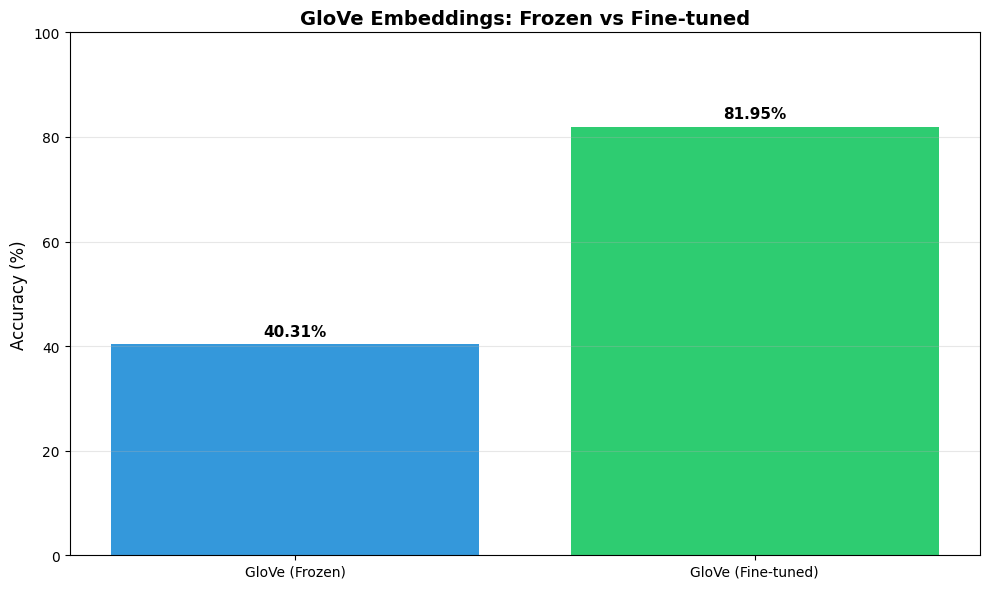


Fine-tuning improvement: +41.64%
✓ Fine-tuning helped improve the model!


In [57]:
# Compare frozen vs fine-tuned GloVe models
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

models_comparison = {
    'GloVe (Frozen)': accuracy_glove * 100,
    'GloVe (Fine-tuned)': accuracy_glove_ft * 100
}

print("\nAccuracy Comparison:")
for model_name, acc in models_comparison.items():
    print(f"  {model_name:25s}: {acc:.2f}%")

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71']
bars = plt.bar(models_comparison.keys(), models_comparison.values(), color=colors)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('GloVe Embeddings: Frozen vs Fine-tuned', fontsize=14, fontweight='bold')
plt.ylim([0, 100])

# Add value labels on bars
for bar, acc in zip(bars, models_comparison.values()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print improvement
improvement = accuracy_glove_ft - accuracy_glove
print(f"\n{'='*70}")
print(f"Fine-tuning improvement: {improvement * 100:+.2f}%")
if improvement > 0:
    print("✓ Fine-tuning helped improve the model!")
elif improvement < 0:
    print("✗ Frozen embeddings performed better (pre-trained knowledge preserved)")
else:
    print("- No significant difference between frozen and fine-tuned")

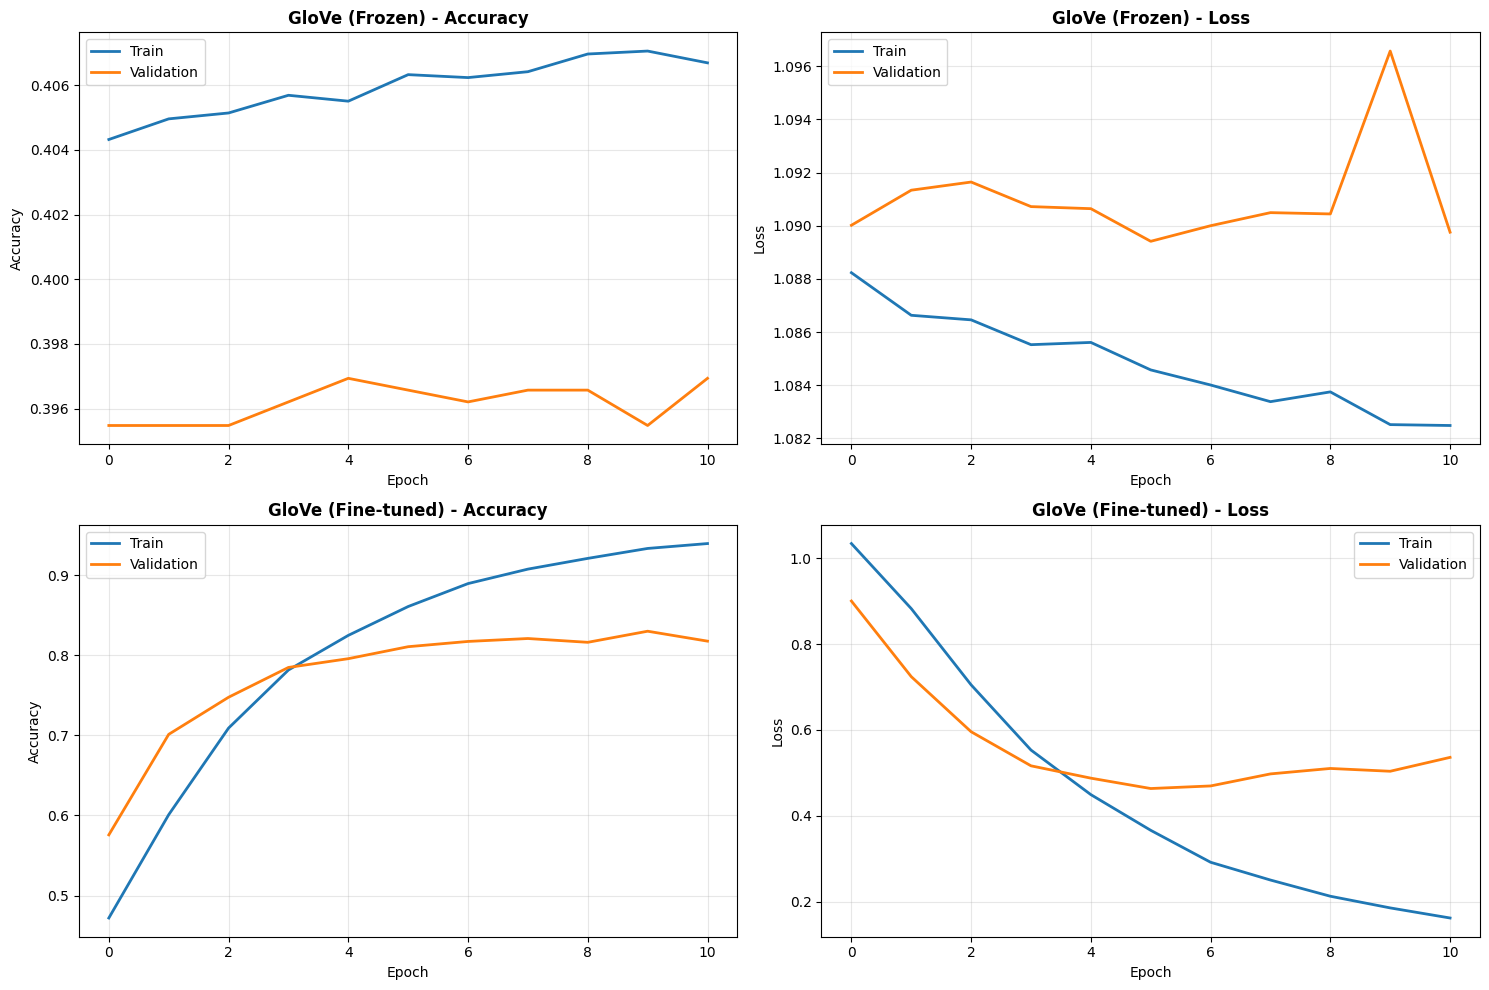

In [58]:
# Compare training histories
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Frozen GloVe - Accuracy
axes[0, 0].plot(history_glove.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history_glove.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('GloVe (Frozen) - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Frozen GloVe - Loss
axes[0, 1].plot(history_glove.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history_glove.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('GloVe (Frozen) - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Fine-tuned GloVe - Accuracy
axes[1, 0].plot(history_glove_ft.history['accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(history_glove_ft.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_title('GloVe (Fine-tuned) - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Fine-tuned GloVe - Loss
axes[1, 1].plot(history_glove_ft.history['loss'], label='Train', linewidth=2)
axes[1, 1].plot(history_glove_ft.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('GloVe (Fine-tuned) - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Bidirectional LSTM layers

Train with bidirectional LSTM layers. Check whether or not the performance (accuracy improves).

In [60]:
# Build model with pre-trained embeddings
vocab_size = len(tokenizer.word_index) + 1

model_glove = Sequential()

# Embedding layer loaded with GloVe weights
# trainable=False freezes the weights - they won't be updated during training
model_glove.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],  # Load pre-trained weights
    input_length=max_sequence_length,
    trainable=False  # Freeze the embeddings
))

# SpatialDropout1D
model_glove.add(SpatialDropout1D(0.2))

# LSTM layer
model_glove.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Dense layers
model_glove.add(Dense(128, activation='relu'))
model_glove.add(Dropout(0.3))

# Output layer
model_glove.add(Dense(3, activation='softmax'))

# Compile
model_glove.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=" * 70)
print("MODEL WITH GLOVE EMBEDDINGS")
print("=" * 70)
model_glove.summary()

# Check that embeddings are frozen
print(f"\n✓ Embedding layer trainable: {model_glove.layers[0].trainable}")
print(f"  (Should be False - weights are frozen)")

MODEL WITH GLOVE EMBEDDINGS


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │     2,594,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,400 (9.90 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,594,400 (9.90 MB)


✓ Embedding layer trainable: False
  (Should be False - weights are frozen)


In [62]:
from tensorflow.keras.layers import Bidirectional

# Build model with Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1

model_glove_bi = Sequential()

# Embedding layer with GloVe weights
model_glove_bi.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_sequence_length,
    trainable=False
))

# SpatialDropout1D
model_glove_bi.add(SpatialDropout1D(0.3))

# Bidirectional LSTM layer
# Processes sequences in both forward and backward directions
# This captures context from both past and future words
model_glove_bi.add(Bidirectional(LSTM(100, dropout=0.2, recurrent_dropout=0.2)))

# Dense layers
model_glove_bi.add(Dense(256, activation='relu'))
model_glove_bi.add(Dropout(0.4))
model_glove_bi.add(Dense(128, activation='relu'))
model_glove_bi.add(Dropout(0.3))

# Output layer
model_glove_bi.add(Dense(3, activation='softmax'))

# Compile
model_glove_bi.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=" * 70)
print("MODEL WITH GLOVE + BIDIRECTIONAL LSTM")
print("=" * 70)
model_glove_bi.summary()

print(f"\n✓ Embedding layer trainable: {model_glove_bi.layers[0].trainable}")
print("✓ Using Bidirectional LSTM (processes sequences forward & backward)")

MODEL WITH GLOVE + BIDIRECTIONAL LSTM


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │     2,594,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,400 (9.90 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,594,400 (9.90 MB)


✓ Embedding layer trainable: False
✓ Using Bidirectional LSTM (processes sequences forward & backward)


In [63]:
# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the regular LSTM model with GloVe
print("Training GloVe + LSTM model...")
print("=" * 70)

history_glove = model_glove.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training complete!")

Training GloVe + LSTM model...
Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - accuracy: 0.4011 - loss: 1.0901 - val_accuracy: 0.3955 - val_loss: 1.0911
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.4061 - loss: 1.0870 - val_accuracy: 0.3958 - val_loss: 1.0903
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - accuracy: 0.4079 - loss: 1.0852 - val_accuracy: 0.3962 - val_loss: 1.0913
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - accuracy: 0.4010 - loss: 1.0875 - val_accuracy: 0.3955 - val_loss: 1.0911
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.4055 - loss: 1.0850 - val_accuracy: 0.3955 - val_loss: 1.0915
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.4059 - loss: 1.0830 - val_accuracy: 0.3955 - val_loss: 1.0917
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.4090 - loss: 1.0827 - val_accuracy: 0.3969 - val_loss: 1.0891
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/st

In [64]:
# Evaluate regular LSTM model
y_pred_glove = model_glove.predict(X_test)
y_pred_classes_glove = np.argmax(y_pred_glove, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy_glove = accuracy_score(y_true, y_pred_classes_glove)

print("=" * 70)
print("GLOVE + LSTM EVALUATION")
print("=" * 70)
print(f"\nTest Accuracy: {accuracy_glove * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_true, y_pred_classes_glove, 
                          target_names=['MWS', 'EAP', 'HPL']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes_glove))

184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
GLOVE + LSTM EVALUATION

Test Accuracy: 40.38%

Classification Report:
              precision    recall  f1-score   support

         MWS       0.50      0.00      0.01      1813
         EAP       0.40      1.00      0.57      2370
         HPL       0.00      0.00      0.00      1691

    accuracy                           0.40      5874
   macro avg       0.30      0.33      0.19      5874
weighted avg       0.32      0.40      0.23      5874


Confusion Matrix:
[[   9 1804    0]
 [   7 2363    0]
 [   2 1689    0]]


In [65]:
# Evaluate Bidirectional LSTM model
y_pred_glove_bi = model_glove_bi.predict(X_test)
y_pred_classes_glove_bi = np.argmax(y_pred_glove_bi, axis=1)

accuracy_glove_bi = accuracy_score(y_true, y_pred_classes_glove_bi)

print("=" * 70)
print("GLOVE + BIDIRECTIONAL LSTM EVALUATION")
print("=" * 70)
print(f"\nTest Accuracy: {accuracy_glove_bi * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_true, y_pred_classes_glove_bi, 
                          target_names=['MWS', 'EAP', 'HPL']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes_glove_bi))

184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step
GLOVE + BIDIRECTIONAL LSTM EVALUATION

Test Accuracy: 28.86%

Classification Report:
              precision    recall  f1-score   support

         MWS       0.31      0.02      0.04      1813
         EAP       0.40      0.00      0.00      2370
         HPL       0.29      0.98      0.45      1691

    accuracy                           0.29      5874
   macro avg       0.33      0.33      0.16      5874
weighted avg       0.34      0.29      0.14      5874


Confusion Matrix:
[[  34    2 1777]
 [  45    2 2323]
 [  31    1 1659]]


PERFORMANCE COMPARISON: LSTM vs BIDIRECTIONAL LSTM

Accuracy Results:
  GloVe + LSTM                  : 40.38%
  GloVe + Bidirectional LSTM    : 28.86%

Improvement with Bidirectional LSTM: -11.53%
✗ Regular LSTM performed better
  → Bidirectional may have caused overfitting


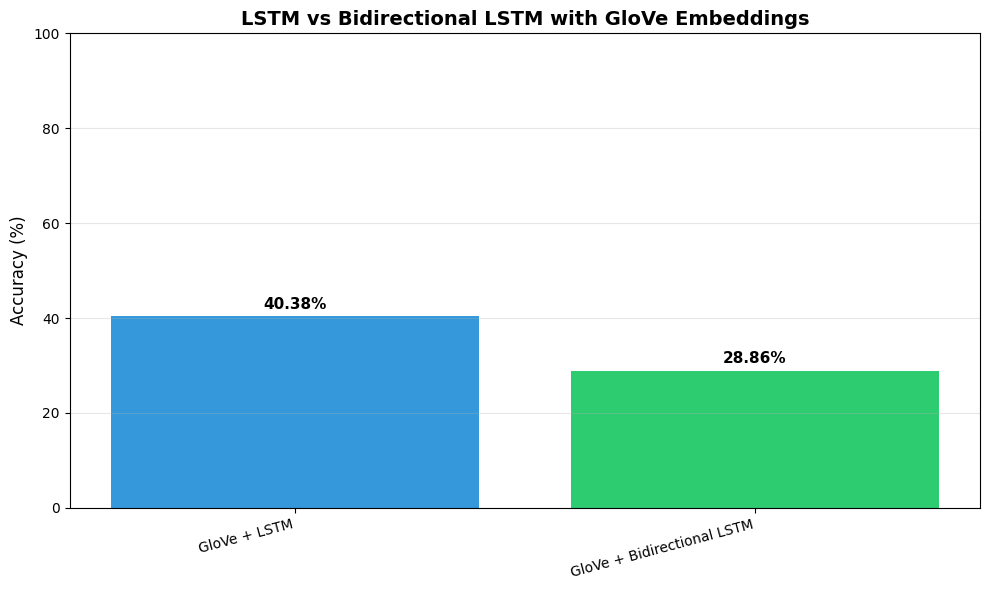

In [66]:
# Compare performance
print("=" * 70)
print("PERFORMANCE COMPARISON: LSTM vs BIDIRECTIONAL LSTM")
print("=" * 70)

comparison = {
    'GloVe + LSTM': accuracy_glove * 100,
    'GloVe + Bidirectional LSTM': accuracy_glove_bi * 100
}

print("\nAccuracy Results:")
for model_name, acc in comparison.items():
    print(f"  {model_name:30s}: {acc:.2f}%")

improvement = accuracy_glove_bi - accuracy_glove
print(f"\nImprovement with Bidirectional LSTM: {improvement * 100:+.2f}%")

if improvement > 0:
    print("✓ Bidirectional LSTM improved performance!")
    print("  → Captures context from both directions")
elif improvement < 0:
    print("✗ Regular LSTM performed better")
    print("  → Bidirectional may have caused overfitting")
else:
    print("- No significant difference")

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71']
bars = plt.bar(comparison.keys(), comparison.values(), color=colors)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('LSTM vs Bidirectional LSTM with GloVe Embeddings', fontsize=14, fontweight='bold')
plt.ylim([0, 100])
plt.xticks(rotation=15, ha='right')

for bar, acc in zip(bars, comparison.values()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Airline Twitter sentiment

The dataset 'Airlines_sentiment.csv' contains tweets about airlines. Your task is to train a sentiment classifier to categorize a tweat into positive, negative or neutral.
The sentiment can be found in the column 'airline_sentiment', the tweets in the column 'text'.



In [69]:
# Reading the Twitter sentiment dataset

dataset = pd.read_csv('Airline_sentiment.csv',encoding = 'ISO-8859-1')
dataset.tail()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,airline_sentiment,airline_sentiment:confidence,negativereason,negativereason:confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_id,tweet_location,user_timezone
14635,681679794,False,finalized,3,2/25/15 19:46,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2/22/15 12:01,5.695880e+17,NaN,NaN
14636,681679795,False,finalized,3,2/25/15 19:14,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2/22/15 11:59,5.695870e+17,Texas,NaN
14637,681679796,False,finalized,3,2/25/15 19:04,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2/22/15 11:59,5.695870e+17,"Nigeria,lagos",NaN
14638,681679797,False,finalized,3,2/25/15 18:59,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2/22/15 11:59,5.695870e+17,New Jersey,Eastern Time (US & Canada)
14639,681679798,False,finalized,3,2/25/15 19:06,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2/22/15 11:58,5.695870e+17,"dallas, TX",NaN


In [76]:
# Try reading with different encodings
try:
    # First try with Latin-1 encoding (common for airline data)
    airline_data = pd.read_csv('./Airline_sentiment.csv', encoding='latin-1')
    print("✓ Successfully loaded with 'latin-1' encoding")
except:
    try:
        # Try ISO-8859-1
        airline_data = pd.read_csv('./Airline_sentiment.csv', encoding='iso-8859-1')
        print("✓ Successfully loaded with 'iso-8859-1' encoding")
    except:
        try:
            # Try Windows-1252
            airline_data = pd.read_csv('./Airline_sentiment.csv', encoding='cp1252')
            print("✓ Successfully loaded with 'cp1252' encoding")
        except Exception as e:
            print(f"❌ Error loading file: {e}")

print("\nDataset shape:", airline_data.shape)
print("\nFirst few rows:")
airline_data.head()

✓ Successfully loaded with 'latin-1' encoding

Dataset shape: (14640, 20)

First few rows:


,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,airline_sentiment,airline_sentiment:confidence,negativereason,negativereason:confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_id,tweet_location,user_timezone
0,681448150,False,finalized,3,2/25/15 5:24,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2/24/15 11:35,5.703060e+17,NaN,Eastern Time (US & Canada)
1,681448153,False,finalized,3,2/25/15 1:53,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2/24/15 11:15,5.703010e+17,NaN,Pacific Time (US & Canada)
2,681448156,False,finalized,3,2/25/15 10:01,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2/24/15 11:15,5.703010e+17,Lets Play,Central Time (US & Canada)
3,681448158,False,finalized,3,2/25/15 3:05,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2/24/15 11:15,5.703010e+17,NaN,Pacific Time (US & Canada)
4,681448159,False,finalized,3,2/25/15 5:50,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2/24/15 11:14,5.703010e+17,NaN,Pacific Time (US & Canada)


In [78]:
# Basic information about the dataset
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(f"\nDataset shape: {airline_data.shape}")
print(f"Columns: {list(airline_data.columns)}")
print(f"\nData types:")
print(airline_data.dtypes)
print(f"\nSample data:")
airline_data[['text', 'airline_sentiment', 'airline']].head(10)

DATASET INFORMATION

Dataset shape: (14640, 20)
Columns: ['_unit_id', '_golden', '_unit_state', '_trusted_judgments', '_last_judgment_at', 'airline_sentiment', 'airline_sentiment:confidence', 'negativereason', 'negativereason:confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_id', 'tweet_location', 'user_timezone']

Data types:
_unit_id                          int64
_golden                            bool
_unit_state                      object
_trusted_judgments                int64
_last_judgment_at                object
airline_sentiment                object
airline_sentiment:confidence    float64
negativereason                   object
negativereason:confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text            

,text,airline_sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America
5,@VirginAmerica seriously would pay $30 a fligh...,negative,Virgin America
6,"@VirginAmerica yes, nearly every time I fly VX...",positive,Virgin America
7,@VirginAmerica Really missed a prime opportuni...,neutral,Virgin America
8,"@virginamerica Well, I didn'tÛ_but NOW I DO! :-D",positive,Virgin America
9,"@VirginAmerica it was amazing, and arrived an ...",positive,Virgin America


SENTIMENT DISTRIBUTION

Sentiment counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment percentages:
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


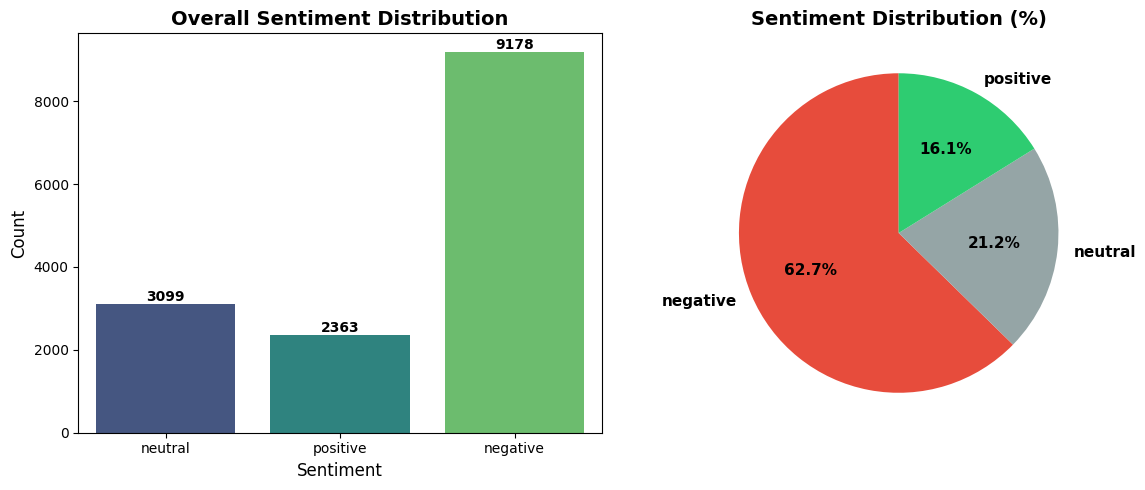


  DATASET IS IMBALANCED!
   Ratio: 3.88:1


In [80]:
# Check the distribution of sentiments
print("=" * 70)
print("SENTIMENT DISTRIBUTION")
print("=" * 70)

sentiment_counts = airline_data['airline_sentiment'].value_counts()
print("\nSentiment counts:")
print(sentiment_counts)
print("\nSentiment percentages:")
print(airline_data['airline_sentiment'].value_counts(normalize=True) * 100)

# Visualize sentiment distribution
plt.figure(figsize=(12, 5))

# Overall sentiment distribution
plt.subplot(1, 2, 1)
sns.countplot(data=airline_data, x='airline_sentiment', palette='viridis')
plt.title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)

# Add count labels on bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

# Sentiment distribution (pie chart)
plt.subplot(1, 2, 2)
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Sentiment Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check if dataset is balanced
if sentiment_counts.max() / sentiment_counts.min() > 3:
    print("\n  DATASET IS IMBALANCED!")
    print(f"   Ratio: {sentiment_counts.max() / sentiment_counts.min():.2f}:1")
else:
    print("\n✓ Dataset is relatively balanced")

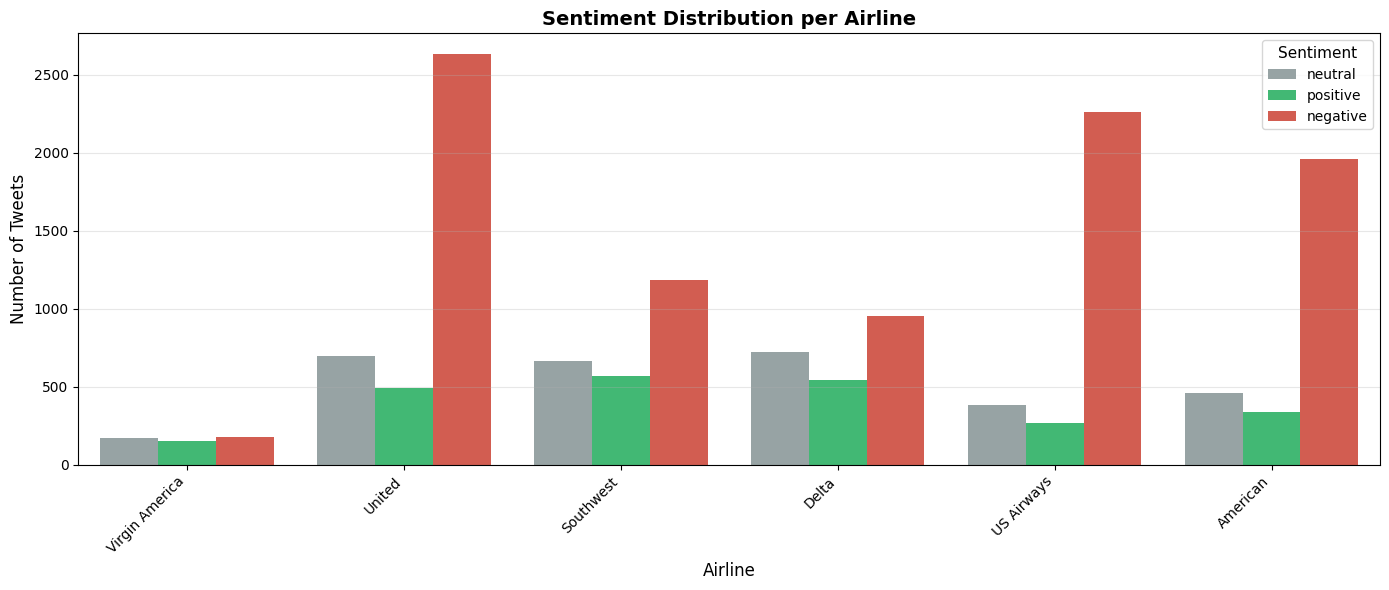


Sentiment counts per airline:
airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152


In [81]:
# Create countplot of sentiment per airline
plt.figure(figsize=(14, 6))
sns.countplot(data=airline_data, x='airline', hue='airline_sentiment', 
              palette={'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'})
plt.title('Sentiment Distribution per Airline', fontsize=14, fontweight='bold')
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', title_fontsize=11, fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics per airline
print("\nSentiment counts per airline:")
print("=" * 70)
airline_sentiment_table = pd.crosstab(airline_data['airline'], airline_data['airline_sentiment'])
print(airline_sentiment_table)

TWEET LENGTH STATISTICS
Longest tweet: 36 words
Shortest tweet: 2 words
Average tweet: 17.65 words
Median tweet: 19 words

LONGEST TWEET:
@JetBlue I _ü Jetblue but i was on flt 277 from fll to sfo. tke off was over 1 hr Late Flight, div to phx &amp; got in 2 hrs Late Flight. What will be done?
(36 words)

SHORTEST TWEET:
@VirginAmerica Thanks!
(2 words)


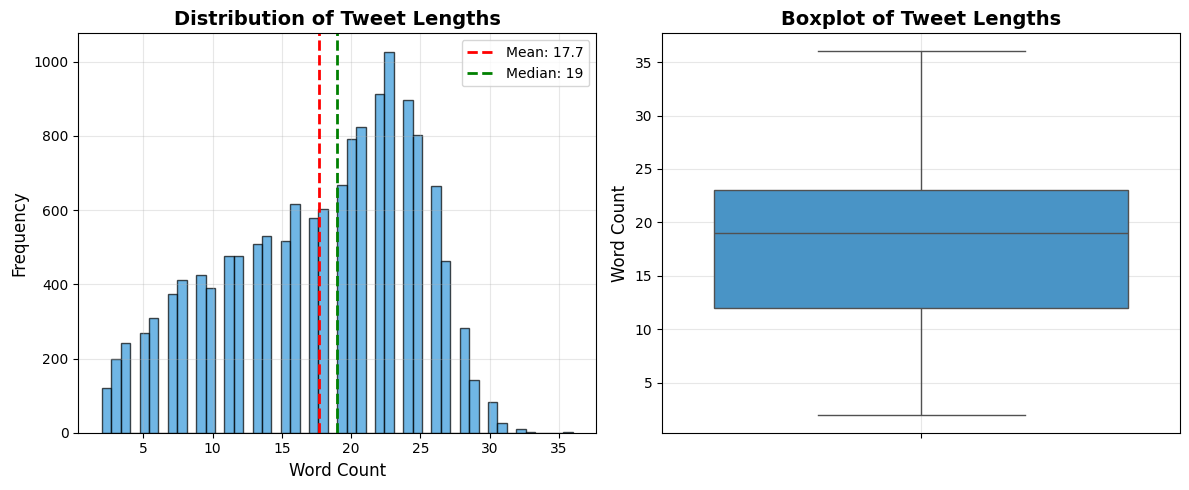

In [82]:
# Analyze tweet lengths in words
airline_data['word_count'] = airline_data['text'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

max_words = airline_data['word_count'].max()
min_words = airline_data['word_count'].min()
avg_words = airline_data['word_count'].mean()
median_words = airline_data['word_count'].median()

print("=" * 70)
print("TWEET LENGTH STATISTICS")
print("=" * 70)
print(f"Longest tweet: {max_words} words")
print(f"Shortest tweet: {min_words} words")
print(f"Average tweet: {avg_words:.2f} words")
print(f"Median tweet: {median_words:.0f} words")

# Show the longest and shortest tweets
print("\n" + "=" * 70)
print("LONGEST TWEET:")
print("=" * 70)
longest_tweet = airline_data.loc[airline_data['word_count'].idxmax(), 'text']
print(f"{longest_tweet}\n({max_words} words)")

print("\n" + "=" * 70)
print("SHORTEST TWEET:")
print("=" * 70)
shortest_tweet = airline_data.loc[airline_data['word_count'].idxmin(), 'text']
print(f"{shortest_tweet}\n({min_words} words)")

# Visualize word count distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(airline_data['word_count'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
plt.axvline(avg_words, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_words:.1f}')
plt.axvline(median_words, color='green', linestyle='--', linewidth=2, label=f'Median: {median_words:.0f}')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(data=airline_data, y='word_count', color='#3498db')
plt.ylabel('Word Count', fontsize=12)
plt.title('Boxplot of Tweet Lengths', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:
# Check for missing values
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

missing_values = airline_data.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\n✓ No missing values found!")
else:
    print(f"\n  Total missing values: {missing_values.sum()}")
    print(f"   Percentage: {(missing_values.sum() / len(airline_data)) * 100:.2f}%")

# Specifically check text and sentiment columns
print("\nChecking critical columns:")
print(f"  Missing in 'text': {airline_data['text'].isnull().sum()}")
print(f"  Missing in 'airline_sentiment': {airline_data['airline_sentiment'].isnull().sum()}")

# Apply listwise deletion (remove rows with any missing values)
original_size = len(airline_data)
airline_data_clean = airline_data.dropna()
removed = original_size - len(airline_data_clean)

print("\n" + "=" * 70)
print("LISTWISE DELETION APPLIED")
print("=" * 70)
print(f"Original size: {original_size}")
print(f"After deletion: {len(airline_data_clean)}")
print(f"Removed rows: {removed} ({(removed/original_size)*100:.2f}%)")

# Verify no missing values remain
print(f"\n✓ Missing values after cleaning: {airline_data_clean.isnull().sum().sum()}")

MISSING VALUES ANALYSIS

Missing values per column:
_last_judgment_at               56
negativereason                5462
negativereason:confidence     4118
airline_sentiment_gold       14600
negativereason_gold          14608
tweet_coord                  13621
tweet_location                4733
user_timezone                 4820
dtype: int64

  Total missing values: 62018
   Percentage: 423.62%

Checking critical columns:
  Missing in 'text': 0
  Missing in 'airline_sentiment': 0

LISTWISE DELETION APPLIED
Original size: 14640
After deletion: 0
Removed rows: 14640 (100.00%)

✓ Missing values after cleaning: 0


In [86]:
# Use the original data if cleaning removed everything
if len(airline_data_clean) == 0:
    print("⚠️ Using original data (no cleaning applied)")
    airline_data_clean = airline_data.copy()
    # Remove only rows where text or sentiment is actually null
    airline_data_clean = airline_data_clean[
        airline_data_clean['text'].notna() & 
        airline_data_clean['airline_sentiment'].notna()
    ]

# Prepare features and labels
X_airline = airline_data_clean['text'].values
y_airline_labels = airline_data_clean['airline_sentiment'].values

# Convert sentiment labels to numbers
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
y_airline_numeric = np.array([sentiment_mapping[label] for label in y_airline_labels])

# One-hot encode the labels
y_airline = to_categorical(y_airline_numeric, num_classes=3)

print("=" * 70)
print("DATA PREPARATION")
print("=" * 70)
print(f"Number of samples: {len(X_airline)}")
print(f"Features shape: {X_airline.shape}")
print(f"Labels shape: {y_airline.shape}")
print(f"\nSentiment mapping:")
for sentiment, code in sentiment_mapping.items():
    print(f"  {sentiment}: {code}")

# Show examples
if len(X_airline) > 0:
    print("\nExample samples:")
    for i in range(min(3, len(X_airline))):
        print(f"\n{i+1}. Text: {X_airline[i][:80]}...")
        print(f"   Sentiment: {y_airline_labels[i]} (encoded: {y_airline_numeric[i]})")
else:
    print("\n ERROR: No data available!")
    print("   Please check the dataset and column names")

⚠️ Using original data (no cleaning applied)
DATA PREPARATION
Number of samples: 14640
Features shape: (14640,)
Labels shape: (14640, 3)

Sentiment mapping:
  negative: 0
  neutral: 1
  positive: 2

Example samples:

1. Text: @VirginAmerica What @dhepburn said....
   Sentiment: neutral (encoded: 1)

2. Text: @VirginAmerica plus you've added commercials to the experience... tacky....
   Sentiment: positive (encoded: 2)

3. Text: @VirginAmerica I didn't today... Must mean I need to take another trip!...
   Sentiment: neutral (encoded: 1)


In [87]:
# Create and train tokenizer
tokenizer_airline = Tokenizer(num_words=10000)  # Limit to top 10k words
tokenizer_airline.fit_on_texts(X_airline)

# Convert to sequences
sequences_airline = tokenizer_airline.texts_to_sequences(X_airline)

# Determine max sequence length (use 95th percentile to avoid outliers)
sequence_lengths = [len(seq) for seq in sequences_airline]
max_len_airline = int(np.percentile(sequence_lengths, 95))

print("=" * 70)
print("TOKENIZATION STATISTICS")
print("=" * 70)
print(f"Vocabulary size: {len(tokenizer_airline.word_index)}")
print(f"Using top {min(10000, len(tokenizer_airline.word_index))} words")
print(f"Max sequence length: {max_len_airline} words")
print(f"Average sequence length: {np.mean(sequence_lengths):.1f} words")

# Pad sequences
X_airline_encoded = pad_sequences(sequences_airline, maxlen=max_len_airline, padding='post')

print(f"\nEncoded data shape: {X_airline_encoded.shape}")
print(f"Example encoded sequence:\n{X_airline_encoded[0]}")

TOKENIZATION STATISTICS
Vocabulary size: 15648
Using top 10000 words
Max sequence length: 27 words
Average sequence length: 17.7 words

Encoded data shape: (14640, 27)
Example encoded sequence:
[  81   62 6713  226    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]


In [88]:
# Split into train and test sets (3000 test samples as required)
X_train_air, X_test_air, y_train_air, y_test_air = train_test_split(
    X_airline_encoded, y_airline,
    test_size=3000,
    random_state=42,
    stratify=y_airline  # Maintain sentiment distribution
)

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)
print(f"Training set size: {len(X_train_air)}")
print(f"Test set size: {len(X_test_air)}")
print(f"Input shape: {X_train_air.shape}")

# Check distribution in train and test sets
y_train_air_labels = np.argmax(y_train_air, axis=1)
y_test_air_labels = np.argmax(y_test_air, axis=1)

reverse_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

print("\nTraining set distribution:")
for i, sentiment in reverse_mapping.items():
    count = np.sum(y_train_air_labels == i)
    print(f"  {sentiment}: {count} ({count/len(y_train_air_labels)*100:.1f}%)")

print("\nTest set distribution:")
for i, sentiment in reverse_mapping.items():
    count = np.sum(y_test_air_labels == i)
    print(f"  {sentiment}: {count} ({count/len(y_test_air_labels)*100:.1f}%)")

TRAIN-TEST SPLIT
Training set size: 11640
Test set size: 3000
Input shape: (11640, 27)

Training set distribution:
  negative: 7297 (62.7%)
  neutral: 2464 (21.2%)
  positive: 1879 (16.1%)

Test set distribution:
  negative: 1881 (62.7%)
  neutral: 635 (21.2%)
  positive: 484 (16.1%)


In [89]:
# Build LSTM model for sentiment classification
vocab_size_airline = min(10000, len(tokenizer_airline.word_index)) + 1

model_sentiment = Sequential()

# Embedding layer
model_sentiment.add(Embedding(vocab_size_airline, 128, input_length=max_len_airline))
model_sentiment.add(SpatialDropout1D(0.3))

# Bidirectional LSTM
model_sentiment.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))

# Dense layers
model_sentiment.add(Dense(128, activation='relu'))
model_sentiment.add(Dropout(0.4))
model_sentiment.add(Dense(64, activation='relu'))
model_sentiment.add(Dropout(0.3))

# Output layer (3 classes: negative, neutral, positive)
model_sentiment.add(Dense(3, activation='softmax'))

# Compile
model_sentiment.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=" * 70)
print("SENTIMENT CLASSIFICATION MODEL")
print("=" * 70)
model_sentiment.summary()

SENTIMENT CLASSIFICATION MODEL


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [90]:
# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("Training sentiment classification model...")
print("=" * 70)

history_sentiment = model_sentiment.fit(
    X_train_air, y_train_air,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training complete!")

Training sentiment classification model...
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5978 - loss: 0.9476 - val_accuracy: 0.7255 - val_loss: 0.6616
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7129 - loss: 0.6337 - val_accuracy: 0.7582 - val_loss: 0.5883
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.7956 - loss: 0.4894 - val_accuracy: 0.7745 - val_loss: 0.5907
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8347 - loss: 0.4284 - val_accuracy: 0.7869 - val_loss: 0.5635
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.8800 - loss: 0.3262 - val_accuracy: 0.7947 - val_loss: 0.5722
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9084 - loss: 0.2697 - val_accuracy: 0.7908 - val_loss: 0.6088
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9276 - loss: 0.2200 - val_accuracy: 0.7887 - val_loss: 0.6525
Epoch 7: early stopping
Restoring model weights from the end of the

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
SENTIMENT MODEL EVALUATION

Test Accuracy: 79.30%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88      1881
     Neutral       0.61      0.56      0.58       635
    Positive       0.76      0.64      0.69       484

    accuracy                           0.79      3000
   macro avg       0.74      0.70      0.72      3000
weighted avg       0.79      0.79      0.79      3000


Confusion Matrix:
[[1715  127   39]
 [ 220  354   61]
 [  76   98  310]]


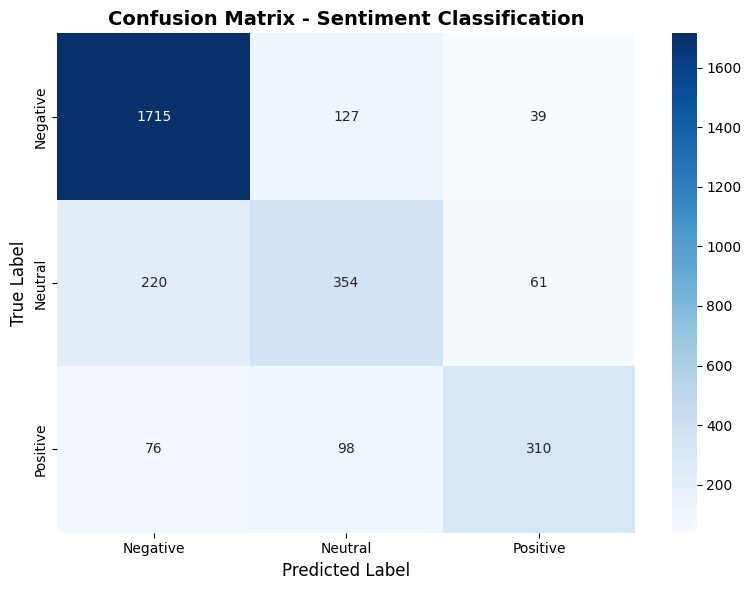

In [91]:
# Evaluate on test set
y_pred_sentiment = model_sentiment.predict(X_test_air)
y_pred_classes_sentiment = np.argmax(y_pred_sentiment, axis=1)
y_true_sentiment = np.argmax(y_test_air, axis=1)

accuracy_sentiment = accuracy_score(y_true_sentiment, y_pred_classes_sentiment)

print("=" * 70)
print("SENTIMENT MODEL EVALUATION")
print("=" * 70)
print(f"\nTest Accuracy: {accuracy_sentiment * 100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true_sentiment, y_pred_classes_sentiment,
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
print("\nConfusion Matrix:")
cm_sentiment = confusion_matrix(y_true_sentiment, y_pred_classes_sentiment)
print(cm_sentiment)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sentiment, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt. title('Confusion Matrix - Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [92]:
# Strategy 1: Use class weights to penalize negative tweet misclassification
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights (giving more importance to negative class)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_air_labels),
    y=y_train_air_labels
)

# Increase weight for negative class even more
class_weights_dict = {0: class_weights[0] * 2, 1: class_weights[1], 2: class_weights[2]}

print("=" * 70)
print("ADJUSTED MODEL FOR NEGATIVE TWEET DETECTION")
print("=" * 70)
print(f"\nClass weights:")
for class_id, weight in class_weights_dict.items():
    print(f"  {reverse_mapping[class_id]}: {weight:.2f}")

# Build new model with same architecture
model_sentiment_adjusted = Sequential()
model_sentiment_adjusted.add(Embedding(vocab_size_airline, 128, input_length=max_len_airline))
model_sentiment_adjusted.add(SpatialDropout1D(0.3))
model_sentiment_adjusted.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))
model_sentiment_adjusted.add(Dense(128, activation='relu'))
model_sentiment_adjusted.add(Dropout(0.4))
model_sentiment_adjusted.add(Dense(64, activation='relu'))
model_sentiment_adjusted.add(Dropout(0.3))
model_sentiment_adjusted.add(Dense(3, activation='softmax'))

model_sentiment_adjusted.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train with class weights
print("\nTraining with class weights to prioritize negative tweet detection...")
history_sentiment_adjusted = model_sentiment_adjusted.fit(
    X_train_air, y_train_air,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights_dict,  # Use class weights
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training complete!")

ADJUSTED MODEL FOR NEGATIVE TWEET DETECTION

Class weights:
  negative: 1.06
  neutral: 1.57
  positive: 2.06

Training with class weights to prioritize negative tweet detection...
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.5807 - loss: 1.3655 - val_accuracy: 0.6847 - val_loss: 0.6869
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7153 - loss: 0.9569 - val_accuracy: 0.7693 - val_loss: 0.5750
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8117 - loss: 0.7344 - val_accuracy: 0.7616 - val_loss: 0.5791
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.8610 - loss: 0.5483 - val_accuracy: 0.7930 - val_loss: 0.5382
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8887 - loss: 0.4683 - val_accuracy: 0.7745 - val_loss: 0.5877
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9086 - loss: 0.3840 - val_accuracy: 0.7951 - val_loss: 0.6148
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accu

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
ADJUSTED MODEL EVALUATION

Test Accuracy: 80.60%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.91      0.89      1881
     Neutral       0.68      0.53      0.60       635
    Positive       0.72      0.76      0.74       484

    accuracy                           0.81      3000
   macro avg       0.75      0.73      0.74      3000
weighted avg       0.80      0.81      0.80      3000


Confusion Matrix:
[[1712  108   61]
 [ 211  339   85]
 [  63   54  367]]

NEGATIVE CLASS PERFORMANCE COMPARISON

Original Model (Negative Class):
  Precision: 0.8528
  Recall: 0.9117
  F1-Score: 0.8813

Adjusted Model (Negative Class):
  Precision: 0.8620
  Recall: 0.9102
  F1-Score: 0.8854

Improvements:
  Recall: -0.16%
  (Higher recall = fewer negative tweets misclassified)


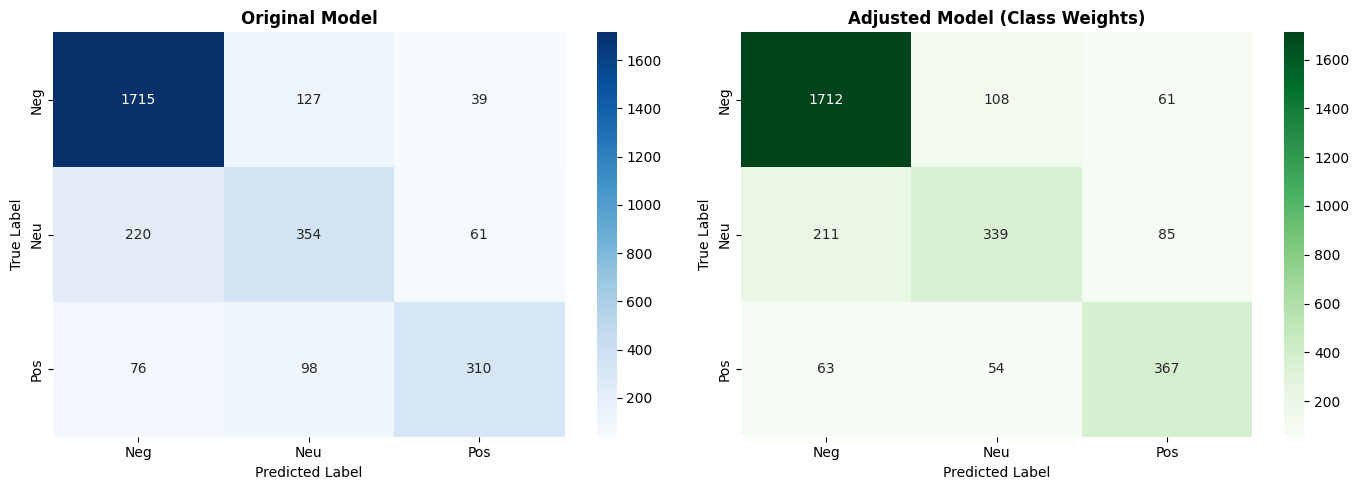

In [93]:
# Evaluate adjusted model
y_pred_adjusted = model_sentiment_adjusted.predict(X_test_air)
y_pred_classes_adjusted = np.argmax(y_pred_adjusted, axis=1)

accuracy_adjusted = accuracy_score(y_true_sentiment, y_pred_classes_adjusted)

print("=" * 70)
print("ADJUSTED MODEL EVALUATION")
print("=" * 70)
print(f"\nTest Accuracy: {accuracy_adjusted * 100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true_sentiment, y_pred_classes_adjusted,
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
print("\nConfusion Matrix:")
cm_adjusted = confusion_matrix(y_true_sentiment, y_pred_classes_adjusted)
print(cm_adjusted)

# Calculate metrics specifically for negative class
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "=" * 70)
print("NEGATIVE CLASS PERFORMANCE COMPARISON")
print("=" * 70)

# Original model
neg_recall_original = recall_score(y_true_sentiment, y_pred_classes_sentiment, 
                                   labels=[0], average=None)[0]
neg_precision_original = precision_score(y_true_sentiment, y_pred_classes_sentiment, 
                                         labels=[0], average=None)[0]
neg_f1_original = f1_score(y_true_sentiment, y_pred_classes_sentiment, 
                           labels=[0], average=None)[0]

# Adjusted model
neg_recall_adjusted = recall_score(y_true_sentiment, y_pred_classes_adjusted, 
                                   labels=[0], average=None)[0]
neg_precision_adjusted = precision_score(y_true_sentiment, y_pred_classes_adjusted, 
                                         labels=[0], average=None)[0]
neg_f1_adjusted = f1_score(y_true_sentiment, y_pred_classes_adjusted, 
                           labels=[0], average=None)[0]

print("\nOriginal Model (Negative Class):")
print(f"  Precision: {neg_precision_original:.4f}")
print(f"  Recall: {neg_recall_original:.4f}")
print(f"  F1-Score: {neg_f1_original:.4f}")

print("\nAdjusted Model (Negative Class):")
print(f"  Precision: {neg_precision_adjusted:.4f}")
print(f"  Recall: {neg_recall_adjusted:.4f}")
print(f"  F1-Score: {neg_f1_adjusted:.4f}")

print("\nImprovements:")
print(f"  Recall: {(neg_recall_adjusted - neg_recall_original)*100:+.2f}%")
print(f"  (Higher recall = fewer negative tweets misclassified)")

# Visualize both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_sentiment, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'])
axes[0].set_title('Original Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)

sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'])
axes[1].set_title('Adjusted Model (Class Weights)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

- Examine the balancedness of the dataset. 
- Make a Seaborn countplot of the sentiment per airline.
- How many words contains the longest twitter message and how many words contains the shortest?
- Look for missing values and apply listwise deletion (remove incomplete samples)
- Split into a training set and test set. Make sure there are 3000 tweets in the test set.
- Train a LSTM/GRU classifier that can predict the sentiment from the tweet as accurately as possible. Test on the test set.
- Suppose that the airlines are mainly interested in correctly detecting negative tweets. What adjustments could you make to ensure that the model misclassifies fewer negative tweets? Test these adjustments.

